In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [18]:
# Load data
df = pd.read_csv('full_image_data_feb_25.csv', low_memory=False)
books = pd.read_csv('full_book_data_feb_25.csv', low_memory=False)

# Merge printers/publishers
printer_pub = books[['book', 'printers', 'publishers']].drop_duplicates(subset=['book'])
df = df.merge(printer_pub, on='book', how='left')

In [19]:
# Filter for target CK keywords
keywords = [
    'CK_Inequality of Natural Days',
    'CK_Circles of Natural Days',
    'CK_Sun Orbit',
    'CK_Movement of the Sun'
]

mask = df['cks'].apply(lambda x: any(kw in str(x) for kw in keywords))
filtered_df = df[mask].copy()

# Add category column
def get_category(cks_val):
    cats = [kw.replace('CK_', '') for kw in keywords if kw in str(cks_val)]
    return ', '.join(cats)

filtered_df['category'] = filtered_df['cks'].apply(get_category)

# Prepare for plotting
filtered_df['custom_identifier_str'] = filtered_df['custom_identifier'].astype(str)
filtered_df['year'] = pd.to_numeric(filtered_df['year'], errors='coerce')
plot_df = filtered_df.dropna(subset=['year', 'place', 'custom_identifier']).copy()
plot_df = plot_df.sort_values(by=['year'])

print(f"Total rows for plotting: {len(plot_df)}")
print(f"Unique books: {plot_df['book'].nunique()}")
print(f"Unique images: {plot_df['images'].nunique()}")

Total rows for plotting: 1216
Unique books: 274
Unique images: 1208


Task was destroyed but it is pending!
task: <Task pending name='Task-160' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-161' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/matplotlib/transforms.py:195: RuntimeWarning:

coroutine 'Kernel.shell_main' was never awaited

Task was destroyed but it is pending!
task: <Task pending name='Task-161' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeu

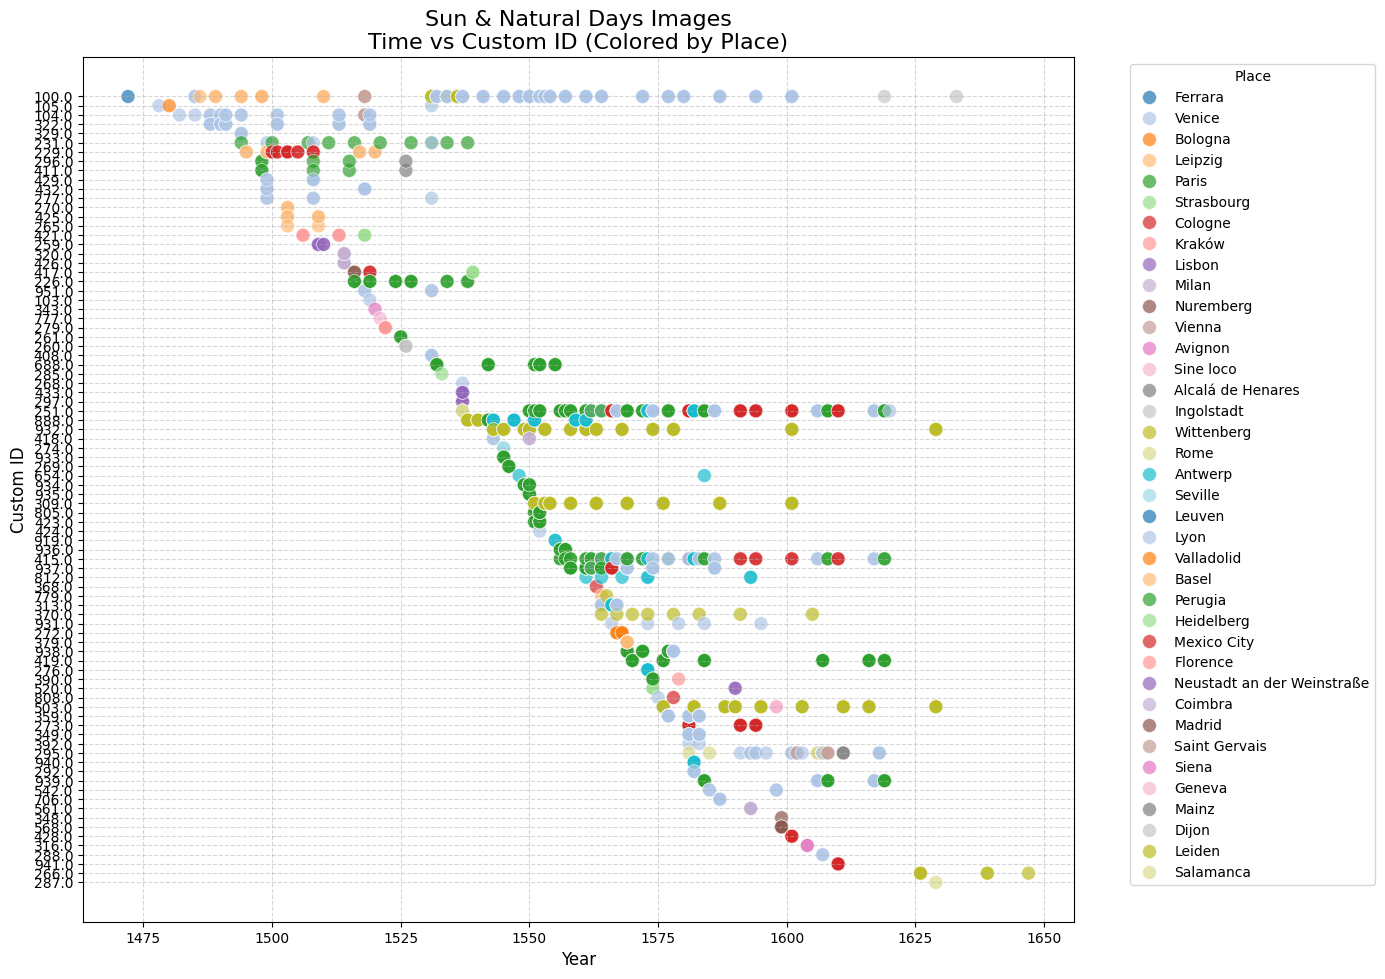

In [20]:
# Static Scatter Plot (Y = Custom ID, Color = Place)
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Sun & Natural Days Images\nTime vs Custom ID (Colored by Place)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
plt.tight_layout()
plt.savefig('sun_days_scatter_by_id.png', dpi=300)
plt.show()

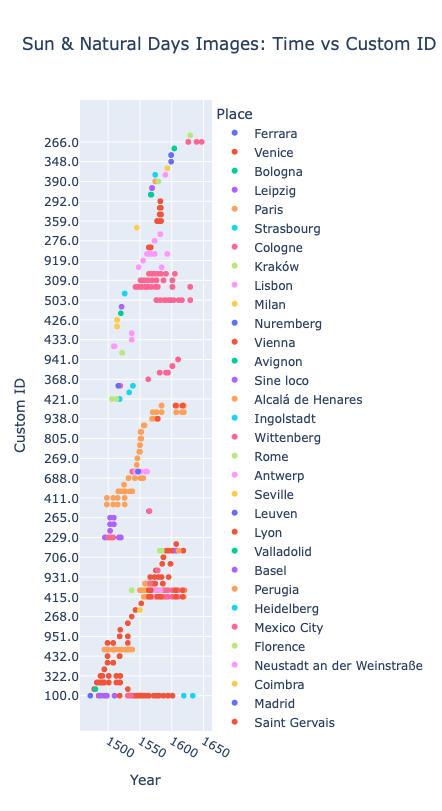

In [21]:
# Interactive Scatter Plot (Y = Custom ID, Color = Place)
fig = px.scatter(
    plot_df,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['category', 'part_or_adaption_label', 'book', 'cks'],
    title='Sun & Natural Days Images: Time vs Custom ID (Interactive)',
    labels={'custom_identifier_str': 'Custom ID', 'year': 'Year', 'place': 'Place'}
)
fig.update_layout(height=800)
fig.show()

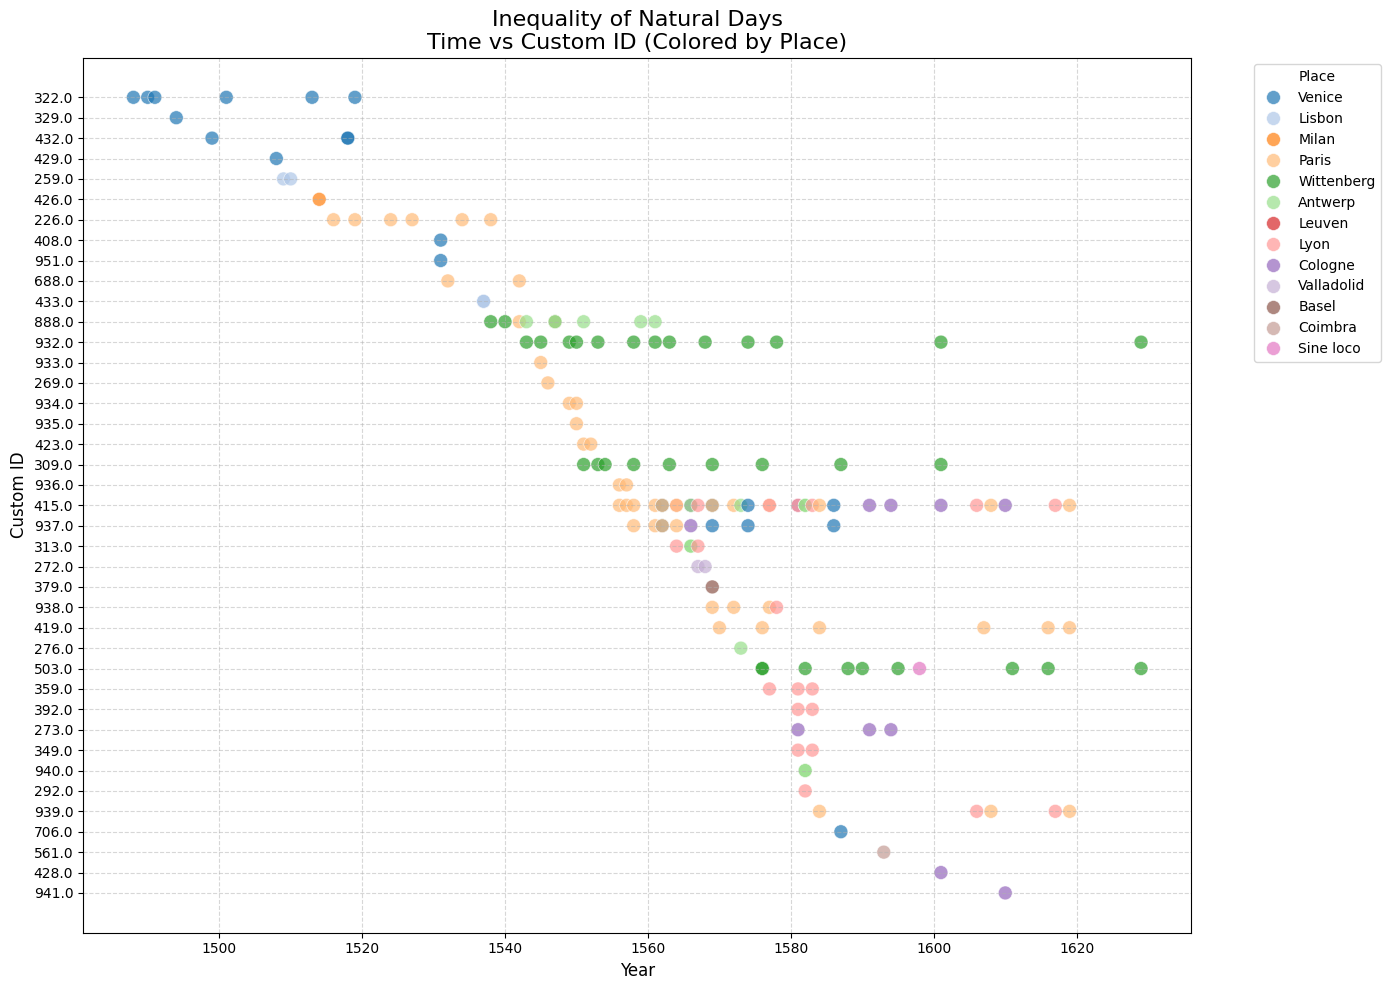

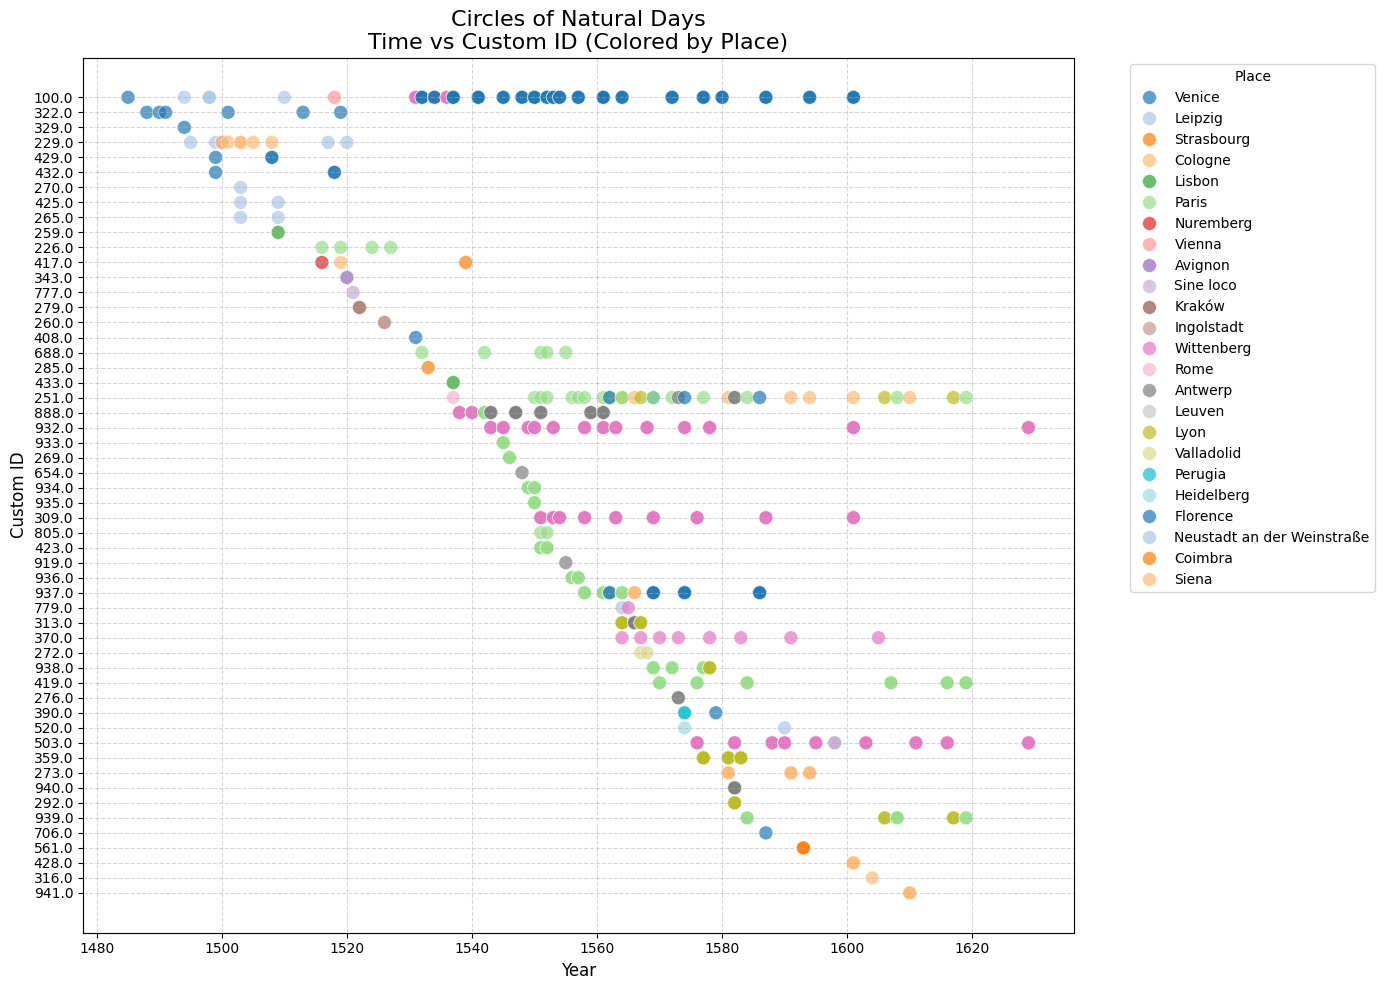

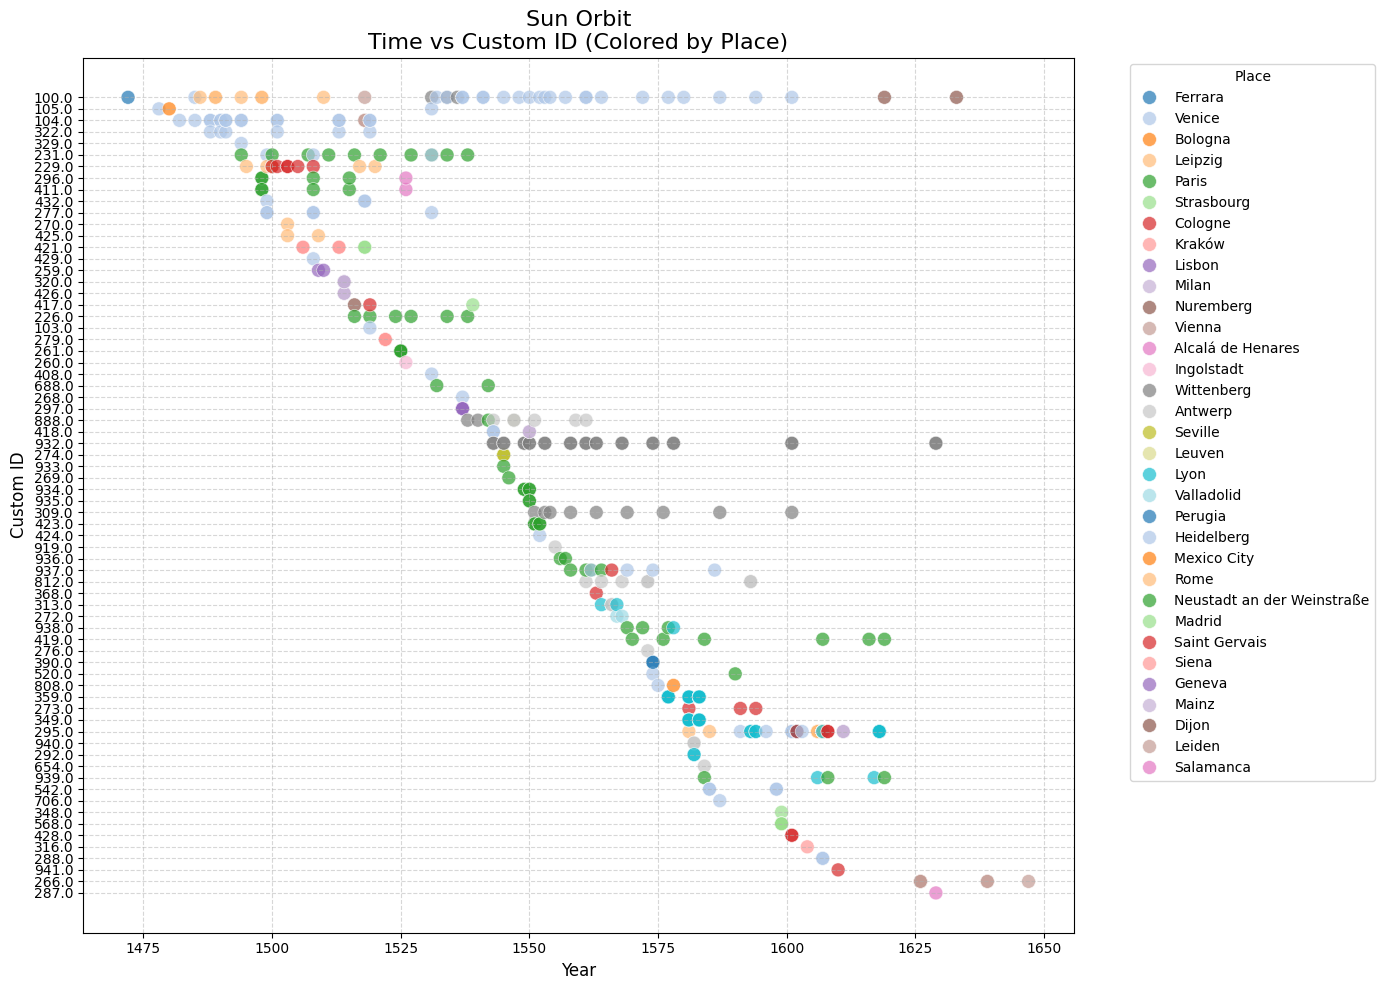

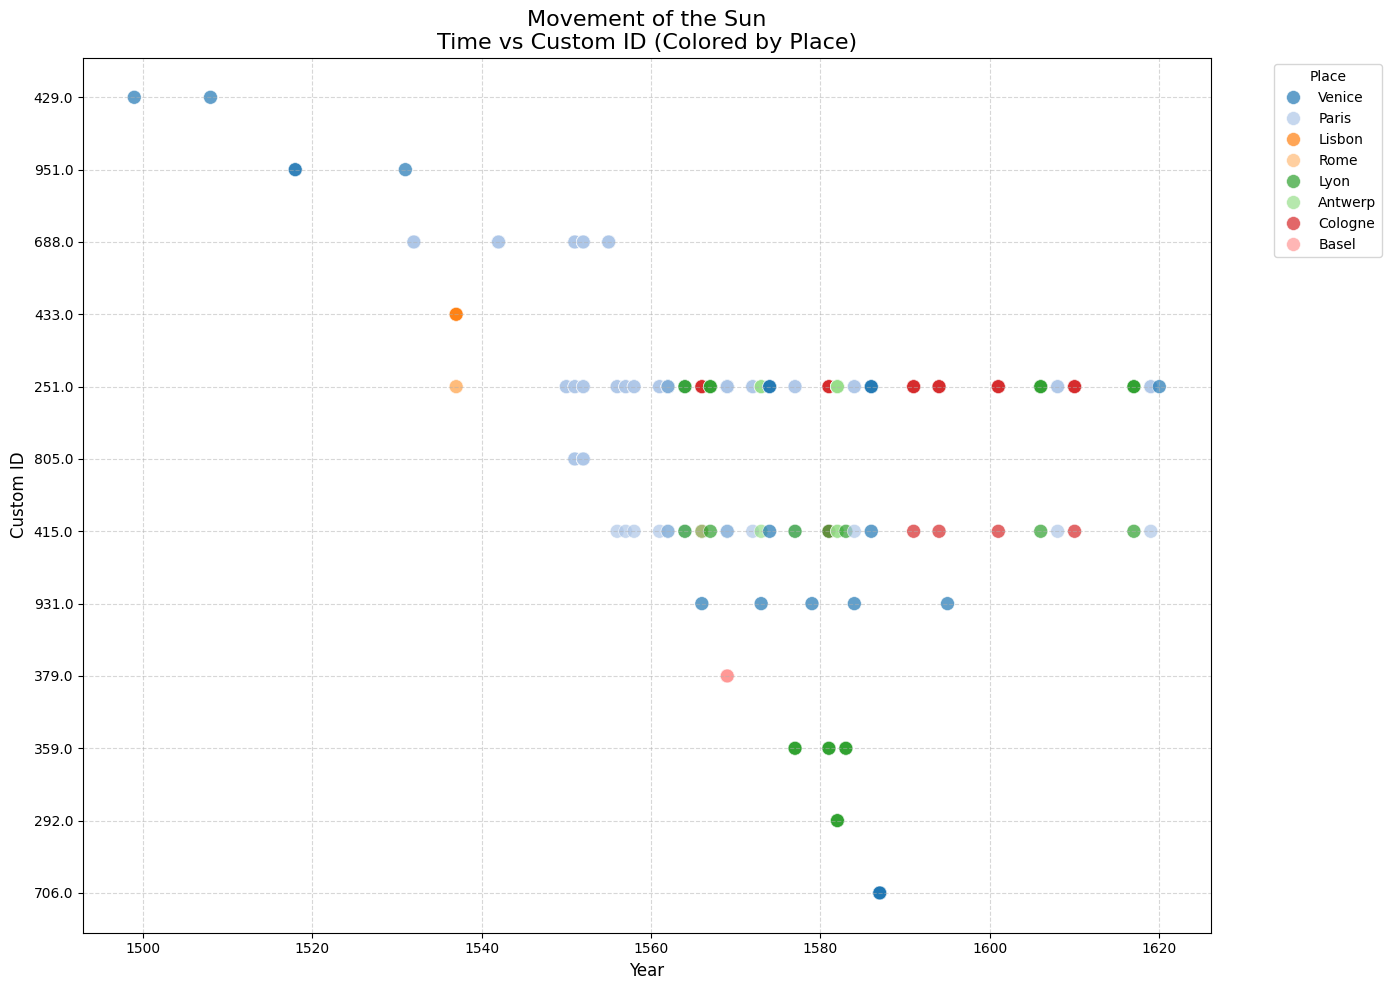

In [22]:
# Individual static scatter plots per CK type
def save_individual_plot(df, cat_name, file_name, title):
    subset = df[df['category'].str.contains(cat_name, na=False)].copy()
    if subset.empty:
        print(f"No data for {cat_name}")
        return

    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=subset,
        x='year',
        y='custom_identifier_str',
        hue='place',
        palette='tab20',
        s=100,
        alpha=0.7,
        edgecolor='w',
        linewidth=0.5
    )
    plt.title(f'{title}\nTime vs Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.show()

for kw in keywords:
    cat_name = kw.replace('CK_', '')
    fname = f"sun_days_{cat_name.replace(' ', '_').lower()}.png"
    save_individual_plot(plot_df, cat_name, fname, cat_name)

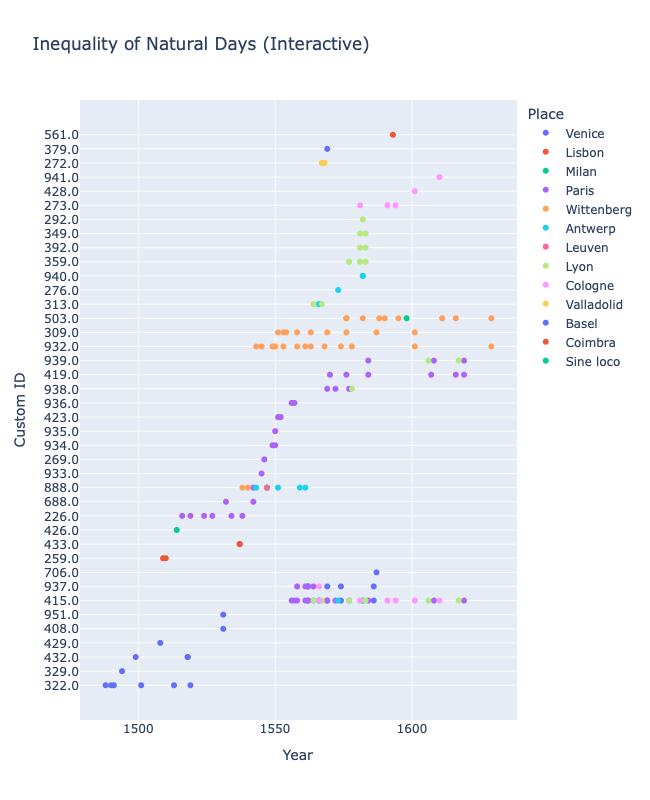

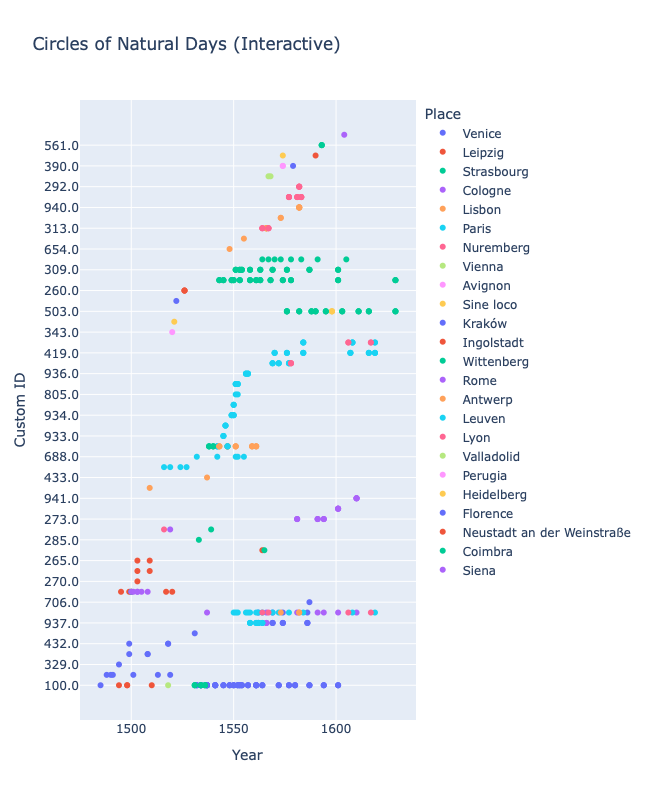

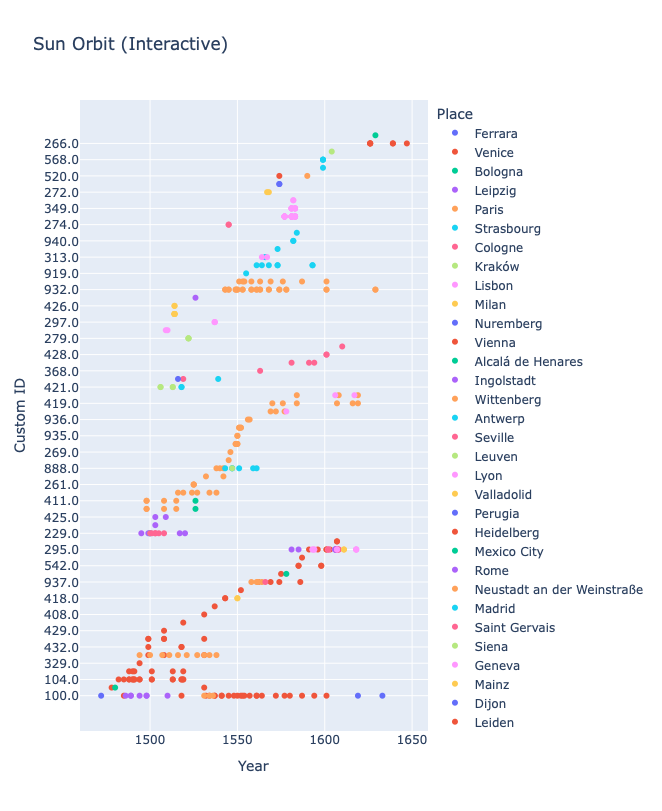

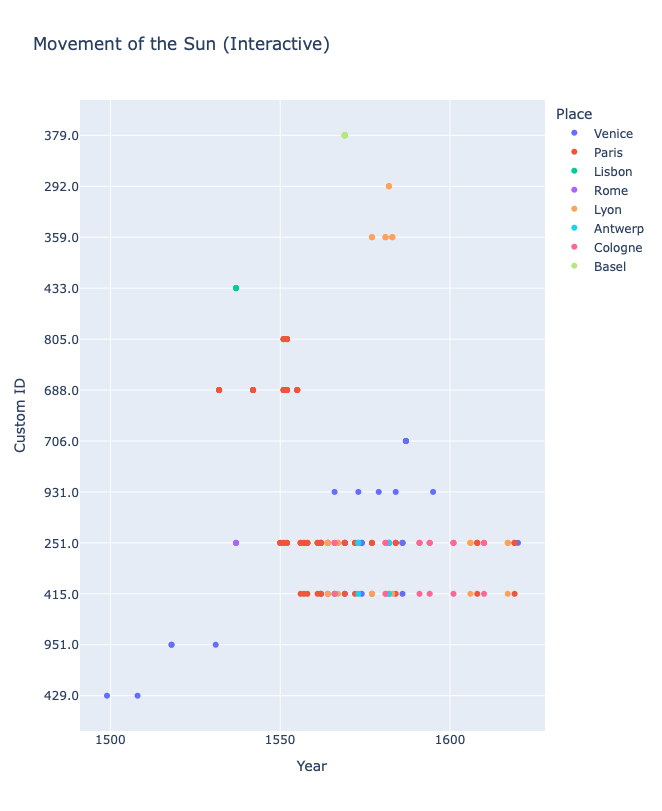

In [23]:
# Individual interactive scatter plots per CK type
def show_dynamic_plot(df, cat_name, title, y_col='custom_identifier_str', color_col='place'):
    subset = df[df['category'].str.contains(cat_name, na=False)].copy()
    if subset.empty:
        print(f"No data for {cat_name}")
        return

    fig = px.scatter(
        subset,
        x='year',
        y=y_col,
        color=color_col,
        hover_data=['category', 'part_or_adaption_label', 'book', 'cks'],
        title=f'{title} (Interactive)',
        labels={'custom_identifier_str': 'Custom ID', 'year': 'Year', 'place': 'Place'}
    )
    fig.update_layout(height=800)
    fig.show()

for kw in keywords:
    cat_name = kw.replace('CK_', '')
    show_dynamic_plot(plot_df, cat_name, cat_name)

In [24]:
# Summary statistics
print("=== Summary Statistics ===")
print(f"Total rows: {len(plot_df)}")
print(f"Unique books: {plot_df['book'].nunique()}")
print(f"Year range: {int(plot_df['year'].min())} - {int(plot_df['year'].max())}")
print(f"\nBooks by publication place:")
print(plot_df['place'].value_counts())

print("\n=== Images per CK type ===")
for kw in keywords:
    cat_name = kw.replace('CK_', '')
    subset = plot_df[plot_df['category'].str.contains(cat_name, na=False)]
    print(f"{kw}: {subset['images'].nunique()} images, {subset['book'].nunique()} books")

=== Summary Statistics ===
Total rows: 1216
Unique books: 274
Year range: 1472 - 1647

Books by publication place:
place
Paris                         301
Venice                        235
Wittenberg                    191
Lyon                          140
Antwerp                        88
Cologne                        84
Leipzig                        30
Basel                          21
Rome                           14
Lisbon                         14
Milan                          10
Kraków                          8
Leiden                          7
Strasbourg                      7
Valladolid                      6
Saint Gervais                   6
Sine loco                       5
Leuven                          5
Ingolstadt                      4
Vienna                          4
Perugia                         4
Coimbra                         4
Madrid                          4
Siena                           2
Alcalá de Henares               2
Dijon                        

## CK_Four Solstices

In [25]:
# Filter for CK_Four Solstices
solstices_df = df[df['cks'].apply(lambda x: 'CK_Four Solstices' in str(x))].copy()
solstices_df['custom_identifier_str'] = solstices_df['custom_identifier'].astype(str)
solstices_df['year'] = pd.to_numeric(solstices_df['year'], errors='coerce')
solstices_plot = solstices_df.dropna(subset=['year', 'place', 'custom_identifier']).sort_values('year')

print(f"Total rows: {len(solstices_plot)}")
print(f"Unique books: {solstices_plot['book'].nunique()}")
print(f"Unique images: {solstices_plot['images'].nunique()}")

Total rows: 40
Unique books: 40
Unique images: 40


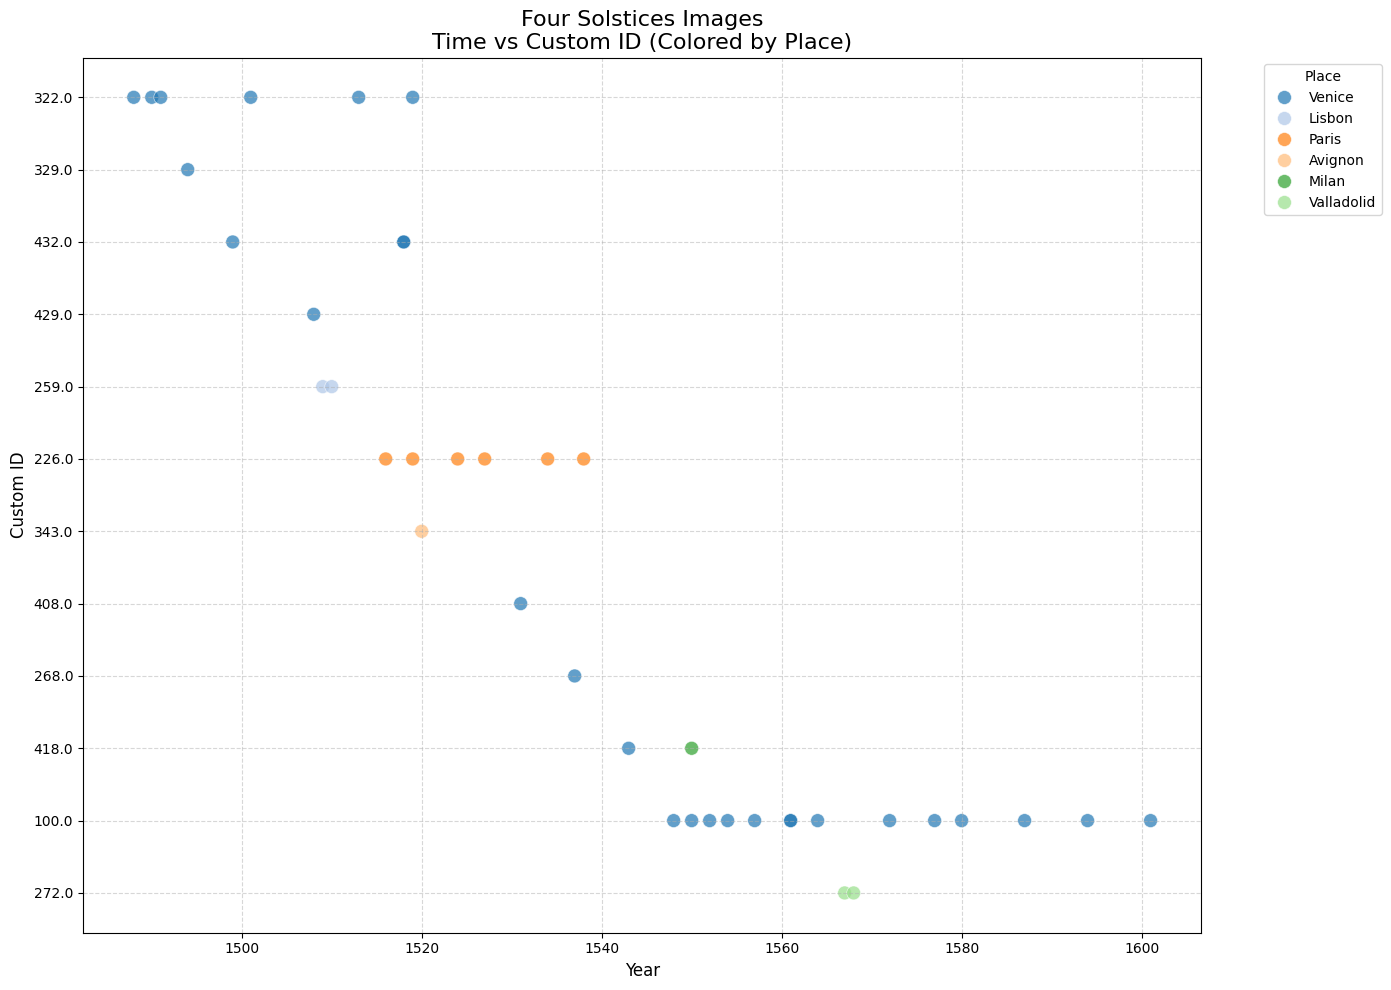

In [26]:
# Static scatter: CK_Four Solstices (Y = Custom ID, Color = Place)
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=solstices_plot,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Four Solstices Images\nTime vs Custom ID (Colored by Place)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
plt.tight_layout()
plt.savefig('sun_days_four_solstices.png', dpi=300)
plt.show()

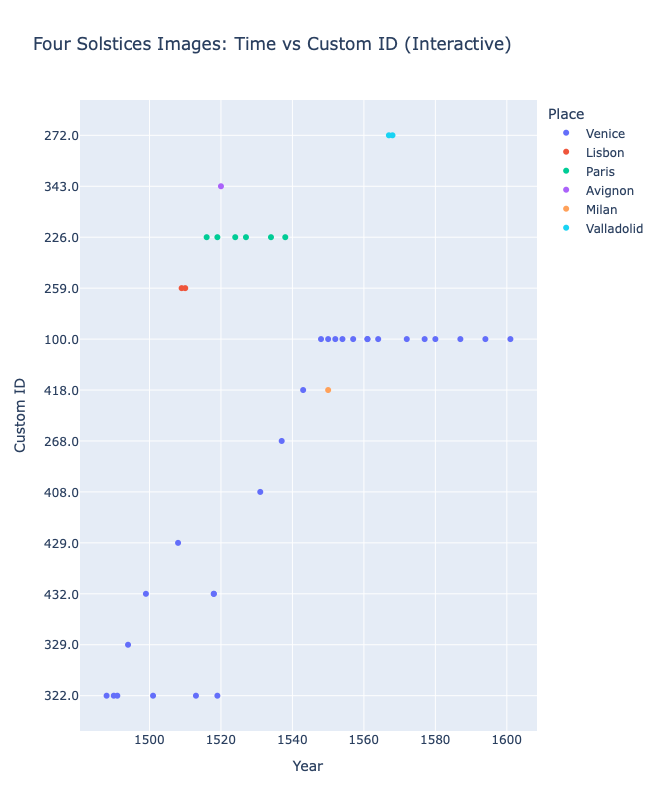

In [27]:
# Interactive scatter: CK_Four Solstices
fig = px.scatter(
    solstices_plot,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['part_or_adaption_label', 'book', 'cks'],
    title='Four Solstices Images: Time vs Custom ID (Interactive)',
    labels={'custom_identifier_str': 'Custom ID', 'year': 'Year', 'place': 'Place'}
)
fig.update_layout(height=800)
fig.show()